# Select a Image input

In [72]:
import sys
sys.path.append('./cpclip_utils') 
from cpclip_utils import generate_example_image


jsonl_path = "/ssd2/xxx/cp_project/data/jsonFile/experimentJsonl_moa/final/val_0903.jsonl"
image_root = "/ssd2/xxx/cp_project/data"
compound_npz_path = "/ssd2/xxx/cp_project/data/jsonFile/experimentJsonl/metadata/all_compounds_embedding.npz"
drug_csv_paths = [
    "/ssd2/xxx/cp_project/data/jsonFile/experimentJsonl/metadata/bbbc021_drugExperiment.csv",
    "/ssd2/xxx/cp_project/data/jsonFile/experimentJsonl/metadata/cpjump_drugExperiment.csv",
    "/ssd2/xxx/cp_project/data/jsonFile/experimentJsonl/metadata/rxrx3_drugExperiment.csv"
]
save_dir = "/ssd2/xxx/cp_project/code/open-clip/tests/example_images"

generate_example_image(
    jsonl_path=jsonl_path,
    image_root=image_root,
    compound_npz_path=compound_npz_path,
    drug_csv_paths=drug_csv_paths,
    save_dir=save_dir
)


=== Final Text ===

Cell line is HUVEC; Cells cultured in EGM2 medium, maintained at 37°C with 5%
CO₂; Image channel is DNA; The imaging objective is 10X; The concentration is
10.0000 μM; The observation time is 20.0 hours; The perturbation compound is
metronidazole; The mechanism of action for this compound is dna inhibitor.

Image saved: /ssd2/xxx/cp_project/code/open-clip/tests/example_images/huvec_dna_10dot0000_20dot0_metronidazole.png


# CPCLIP - context alignment

In [1]:
from cpagent_utils import *
device = torch.device("cuda:7" if torch.cuda.is_available() else "cpu")
matcher = DrugTextImageMatcher(
    open_clip_path="/ssd2/xxx/cp_project/code/open-clip/src",
    pretrained_ckpt_path="/ssd2/xxx/cp_project/data/logs/ViT-B-16-experiment8/2025_09_03-06_18_00-model_ViT-B-16-lr_0.001-b_175-j_4-p_fp32/checkpoints/epoch_35.pt",
    image_base_dir="/ssd2/xxx/cp_project/data",
    text_jsonl="/ssd2/xxx/cp_project/data/jsonFile/experimentJsonl_moa/final/train_dedup.jsonl",
    compound_npz_path="/ssd2/xxx/cp_project/data/jsonFile/experimentJsonl/metadata/all_compounds_embedding.npz",
    drug_csv_paths=[
        "/ssd2/xxx/cp_project/data/jsonFile/experimentJsonl/metadata/bbbc021_drugExperiment.csv",
        "/ssd2/xxx/cp_project/data/jsonFile/experimentJsonl/metadata/cpjump_drugExperiment.csv",
        "/ssd2/xxx/cp_project/data/jsonFile/experimentJsonl/metadata/rxrx3_drugExperiment.csv"
    ],
    device=device
)

final_text, left_img, right_img = matcher.run("/ssd2/xxx/cp_project/code/open-clip/tests/example_images/mcf7_dna_100dot0000_24dot0_alln.png")


/ssd2/xxx/miniconda3/envs/vistaprofilerclip/lib/python3.9/site-packages/torch/cuda/__init__.py:63: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]
/ssd2/xxx/miniconda3/envs/vistaprofilerclip/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


get_tokenizer called with model_name: ViT-B-16, context_length: 256, tokenizer_type: hf:gpt2
Added 3 special tokens to gpt2 tokenizer
   <CONC_TOKEN> -> ID: 50257
   <TIME_TOKEN> -> ID: 50258
   <COMPOUND_TOKEN> -> ID: 50259
Set pad_token to eos_token for GPT tokenizer
[Auto] Fetched special token IDs from tokenizer: {'<CONC_TOKEN>': 50257, '<TIME_TOKEN>': 50258, '<COMPOUND_TOKEN>': 50259}


Encoding: 100%|██████████| 301/301 [00:25<00:00, 11.76it/s]



 The most matching drug condition listed as below:
----------------------------------------
Text:      Cell line is MCF7; Cells cultured in RPMI 1640 medium with 10% fetal bovine serum, 1% GlutaMAX, and 900 μg/mL G418, maintained at 37°C with 5% CO₂; Image channel is DNA; The imaging objective is 20X; The concentration is <CONC_TOKEN>; The observation time is <TIME_TOKEN>; The perturbation compound is <COMPOUND_TOKEN>; The mechanism of action for this compound is protein degradation.
Time:         24 hours
Concentration:100.0000 uM
Compound:     alln
Similarity score:   0.6328
----------------------------------------


In [ ]:
experiment = f"data1"
segmenter = CellSegmentor(
    model_ckpt_path="/ssd2/xxx/cp_project/code/models/model_tuned.pt",
    device=device
)
pipeline_paths = {
    "DNA": "/ssd2/xxx/cp_project/code/cp-agent/featureExtractor/generalPipelines/dnaprofiler.cppipe",
    "AGP": "/ssd2/xxx/cp_project/code/cp-agent/featureExtractor/generalPipelines/agpprofiler.cppipe",
    "ER": "/ssd2/xxx/cp_project/code/cp-agent/featureExtractor/generalPipelines/erprofiler.cppipe",
    "Mito": "/ssd2/xxx/cp_project/code/cp-agent/featureExtractor/generalPipelines/mitoprofiler.cppipe",
    "RNA": "/ssd2/xxx/cp_project/code/cp-agent/featureExtractor/generalPipelines/rnaprofiler.cppipe",
    "Actin": "/ssd2/xxx/cp_project/code/cp-agent/featureExtractor/generalPipelines/actinprofiler.cppipe",
    "Tubulin": "/ssd2/xxx/cp_project/code/cp-agent/featureExtractor/generalPipelines/tubulinprofiler.cppipe",
}
extractor = CellProfilerFeatureExtractor(
    pipeline_paths=pipeline_paths,
    output_base_dir=f"../resoning_results/{experiment}/feature_output",
    temp_input_base_dir=f"../resoning_results/{experiment}/temp_input"
)

CellSamWrapper auto_resize_inputs True network_resize_roi [1024, 1024] checkpoint None


# Generate reports


 Running experiment: data1


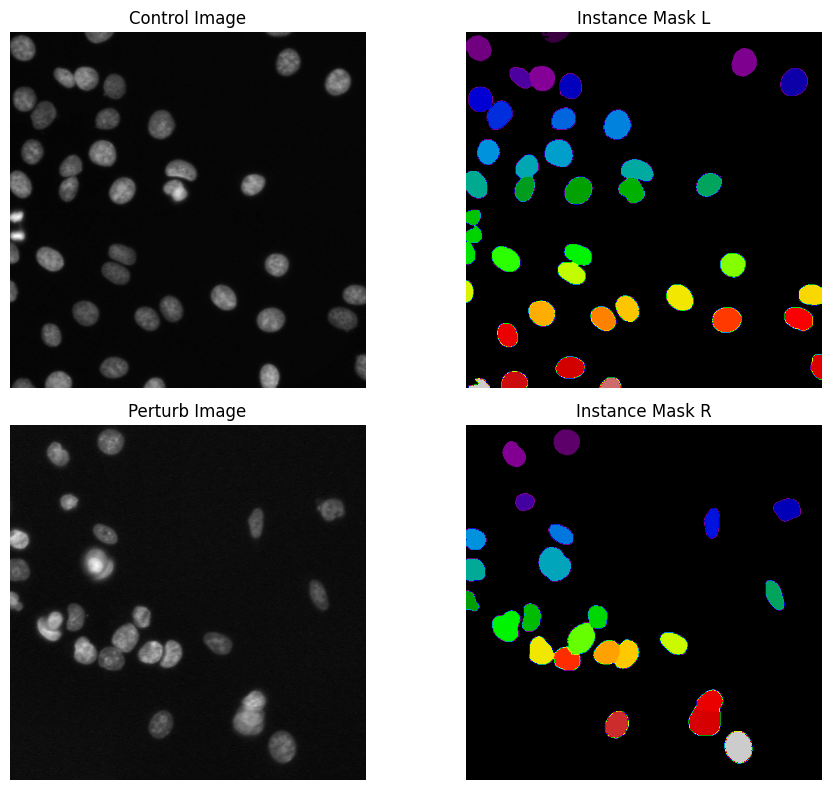

In [ ]:
import re
import json
from contextlib import suppress
import matplotlib.pyplot as plt


# models = ["Grok-4", "GPT-5", "gemini-2.5-pro", "Claude-Sonnet-4"]
models = ["GPT-5"]
print(f"\n Running experiment: {experiment}")

output_dir = f"../resoning_results/{experiment}"
os.makedirs(output_dir, exist_ok=True)


with open(os.path.join(output_dir, "match_result.txt"), "w", encoding="utf-8") as f:
    f.write("GT: " + final_text + "\n\n")
    f.write("Best Match: " + final_text + "\n")

#  Cell Segmentation
left_mask, right_mask, fig = segmenter.segment_and_plot(left_img, right_img)


In [ ]:
# feature extraction
match = re.search(r"Image channel is ([^;]+)", final_text)
channel_type = match.group(1).strip()
feature_level = "nuclei" if channel_type == "DNA" else "cell"
extractor.run_cp_on_pair(left_img, left_mask, "control", channel_type)
extractor.run_cp_on_pair(right_img, right_mask, "perturb", channel_type)
control_df, perturb_df, selected_features, control_csv, perturb_csv = extractor.extract_features(
    channel_type=channel_type,
    feature_level=feature_level
)


Running CellProfiler for: control | Channel: DNA
Image: ../resoning_results/data1/temp_input/control/DNA/default/image/DNA/control_DNA.png
Mask:  ../resoning_results/data1/temp_input/control/DNA/default/mask/nuclei/control_nuclei.png
Command: cellprofiler -c -r -p /ssd2/xxx/cp_project/code/cp-agent/featureExtractor/generalPipelines/dnaprofiler.cppipe -i ../resoning_results/data1/temp_input/control/DNA/default -o ../resoning_results/data1/feature_output/control/DNA/default


Times reported are CPU and Wall-clock times for each module
Sun Sep 28 06:43:16 2025: Image # 1, module Images # 1: CPU_time = 0.00 secs, Wall_time = 0.00 secs
Sun Sep 28 06:43:16 2025: Image # 1, module Metadata # 2: CPU_time = 0.00 secs, Wall_time = 0.00 secs
Sun Sep 28 06:43:16 2025: Image # 1, module NamesAndTypes # 3: CPU_time = 1.55 secs, Wall_time = 0.33 secs
Sun Sep 28 06:43:17 2025: Image # 1, module Groups # 4: CPU_time = 0.00 secs, Wall_time = 0.00 secs
Sun Sep 28 06:43:17 2025: Image # 1, module MeasureImageAreaOccupied # 5: CPU_time = 0.01 secs, Wall_time = 0.01 secs
Sun Sep 28 06:43:17 2025: Image # 1, module MeasureObjectNeighbors # 6: CPU_time = 0.11 secs, Wall_time = 0.11 secs
Sun Sep 28 06:43:17 2025: Image # 1, module MeasureObjectNeighbors # 7: CPU_time = 0.20 secs, Wall_time = 0.21 secs
Sun Sep 28 06:43:17 2025: Image # 1, module MeasureObjectSizeShape # 8: CPU_time = 0.55 secs, Wall_time = 0.54 secs
Sun Sep 28 06:43:18 2025: Image # 1, module MeasureObjectIntensit

CellProfiler finished for: control
Feature CSV saved: ../resoning_results/data1/feature_output/control/DNA/default/Expt_Image.csv

Running CellProfiler for: perturb | Channel: DNA
Image: ../resoning_results/data1/temp_input/perturb/DNA/default/image/DNA/perturb_DNA.png
Mask:  ../resoning_results/data1/temp_input/perturb/DNA/default/mask/nuclei/perturb_nuclei.png
Command: cellprofiler -c -r -p /ssd2/xxx/cp_project/code/cp-agent/featureExtractor/generalPipelines/dnaprofiler.cppipe -i ../resoning_results/data1/temp_input/perturb/DNA/default -o ../resoning_results/data1/feature_output/perturb/DNA/default


Times reported are CPU and Wall-clock times for each module
Sun Sep 28 06:43:25 2025: Image # 1, module Images # 1: CPU_time = 0.00 secs, Wall_time = 0.00 secs
Sun Sep 28 06:43:25 2025: Image # 1, module Metadata # 2: CPU_time = 0.00 secs, Wall_time = 0.00 secs
Sun Sep 28 06:43:25 2025: Image # 1, module NamesAndTypes # 3: CPU_time = 1.57 secs, Wall_time = 0.34 secs
Sun Sep 28 06:43:25 2025: Image # 1, module Groups # 4: CPU_time = 0.00 secs, Wall_time = 0.00 secs
Sun Sep 28 06:43:25 2025: Image # 1, module MeasureImageAreaOccupied # 5: CPU_time = 0.01 secs, Wall_time = 0.01 secs
Sun Sep 28 06:43:25 2025: Image # 1, module MeasureObjectNeighbors # 6: CPU_time = 0.10 secs, Wall_time = 0.10 secs
Sun Sep 28 06:43:25 2025: Image # 1, module MeasureObjectNeighbors # 7: CPU_time = 0.17 secs, Wall_time = 0.17 secs
Sun Sep 28 06:43:25 2025: Image # 1, module MeasureObjectSizeShape # 8: CPU_time = 0.51 secs, Wall_time = 0.51 secs
Sun Sep 28 06:43:26 2025: Image # 1, module MeasureObjectIntensit

CellProfiler finished for: perturb
Feature CSV saved: ../resoning_results/data1/feature_output/perturb/DNA/default/Expt_Image.csv

Loading Control CSV: ../resoning_results/data1/feature_output/control/DNA/default/Expt_nuclei.csv
Loading Perturb CSV: ../resoning_results/data1/feature_output/perturb/DNA/default/Expt_nuclei.csv

Filtered 246 features from channel: DNA


In [ ]:
for model_name in models:
    print(f"{experiment} | Model: {model_name}")

    analyzer = LLMFeatureAnalyzer(
        api_key="XXXX",
        prompt_yaml_path_step1="/ssd2/xxx/cp_project/code/open-clip/tests/reasoning_utils/featRank.yaml",
        prompt_yaml_path_step3="/ssd2/xxx/cp_project/code/open-clip/tests/reasoning_utils/reportGen.yaml",
        final_text=final_text,
        feature_names=selected_features,
        control_profiler_csv=control_csv,
        perturb_profiler_csv=perturb_csv,
        left_img=left_img,
        right_img=right_img,
        model=model_name,
        base_url="https://api.poe.com/v1",
        use_data_url_images=True,
    )


print(f"\n▶▶▶ {model_name} started for {experiment}\n")
feature_response = analyzer.step1_generate_background_and_features()
print(f"\n--- Step 1: Feature Response ---")
print(json.dumps(feature_response, indent=2, ensure_ascii=False))

data1 | Model: GPT-5

▶▶▶ GPT-5 started for data1


[Step 1A] Generating background...

[Step 1B] Predicting features...

--- Step 1: Feature Response ---
{
  "thoughts": "",
  "answer": "{\n  \"features_ranked\": [\n    {\n      \"name\": \"AreaShape_Area\",\n      \"rationale\": \"Proteasome/calpain inhibition can trigger apoptosis or mitotic arrest, yielding nuclear pyknosis (smaller area) or mitotic condensation (transiently smaller, brighter nuclei), shifting the nuclear area distribution.\",\n      \"confidence\": 0.76\n    },\n    {\n      \"name\": \"AreaShape_Eccentricity\",\n      \"rationale\": \"Apoptotic and mechanically stressed nuclei often become more elongated/irregular; calpain inhibition can alter nuclear shape via cytoskeletal coupling.\",\n      \"confidence\": 0.66\n    },\n    {\n      \"name\": \"AreaShape_Solidity\",\n      \"rationale\": \"Nuclear fragmentation and irregular contours decrease solidity due to increased concavity and lobulation.\",\n      \"conf

In [10]:
stats = analyzer.step2_compute_feature_statistics()
print(f"\n--- Step 2: Feature Statistics ---")
print(json.dumps(stats, indent=2, ensure_ascii=False))

Computing statistics: 100%|██████████| 20/20 [00:01<00:00, 13.82it/s]


--- Step 2: Feature Statistics ---
{
  "number_of_cells_control": 41,
  "number_of_cells_perturb": 24,
  "records": [
    {
      "feature": "Texture_Entropy_DNA_5_02_256",
      "n_control": 41,
      "n_perturb": 24,
      "median_control": 9.25340856086541,
      "median_perturb": 10.098689739998587,
      "mad_control": 0.5677876287583423,
      "mad_perturb": 0.3520315003399972,
      "p10_control": 8.21998525863971,
      "p25_control": 8.729670406118785,
      "p50_control": 9.25340856086541,
      "p75_control": 9.821196189623752,
      "p90_control": 10.222960705162228,
      "p10_perturb": 9.549274095305801,
      "p25_perturb": 9.739129538839073,
      "p50_perturb": 10.098689739998587,
      "p75_perturb": 10.423349938335996,
      "p90_perturb": 10.762729070057127,
      "delta_median": 0.8452811791331776,
      "bootstrap_ci_lower": 0.5311467344853842,
      "bootstrap_ci_upper": 1.242168829542036,
      "cliffs_delta": -0.6605691056910569,
      "p_value": 1.02900354988


--- Step 3: Report (without answer) ---
{
  "thoughts": ""
}

--- LLM Answer (raw) ---
{
  "features_ranked": [
    {
      "name": "Texture_Entropy_DNA_5_02_256",
      "direction": "increase",
      "observed_evidence": "Median increased by 0.85 with CI [0.53, 1.24], Cliff’s delta 0.661 (q=1.35e-4), strong effect.",
      "mechanism_link": "Higher nuclear entropy indicates more DNA intensity heterogeneity/condensation variability, consistent with proteasome/calpain inhibition causing chromatin condensation, fragmentation, or mixed cell-cycle states.",
      "supports_proposed_mechanism": "supports",
      "support_confidence": 0.9
    },
    {
      "name": "Texture_DifferenceEntropy_DNA_5_02_256",
      "direction": "increase",
      "observed_evidence": "Median increased by 0.78 with CI [0.25, 1.17], Cliff’s delta 0.650 (q=1.35e-4).",
      "mechanism_link": "Greater difference-entropy reflects increased local unpredictability in nuclear texture, compatible with stress-induced chr

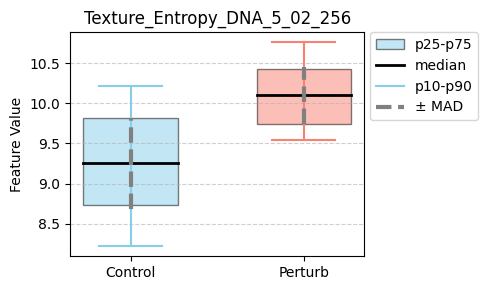

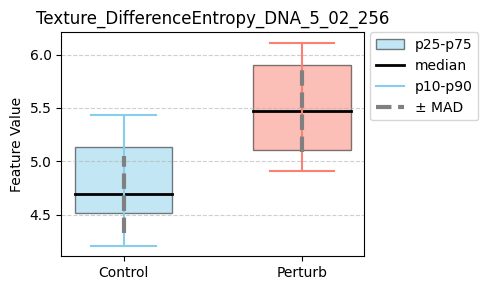

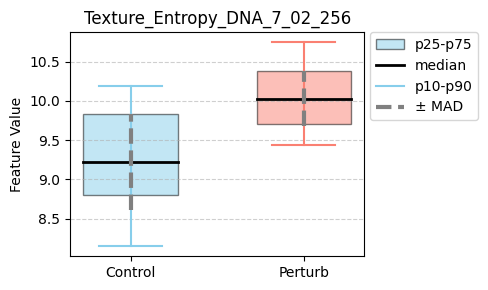

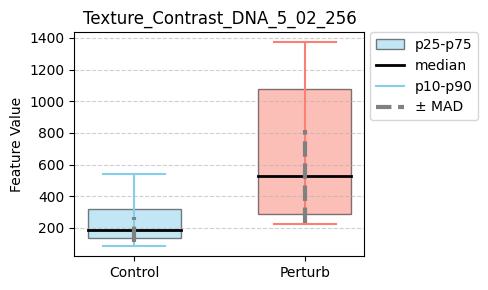

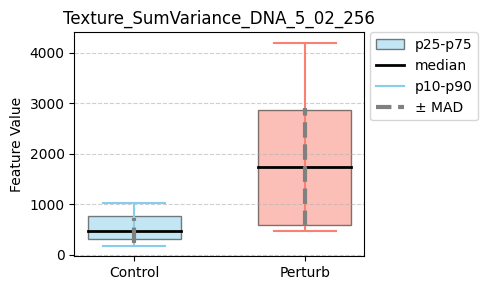

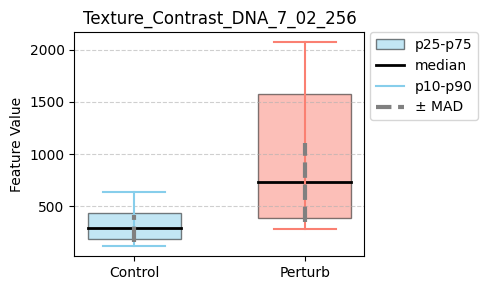

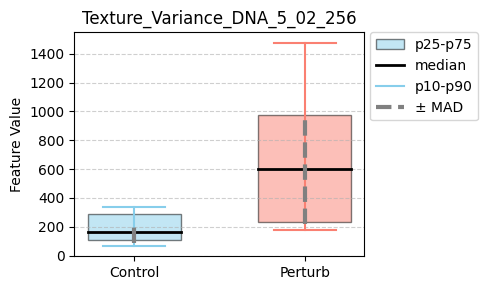

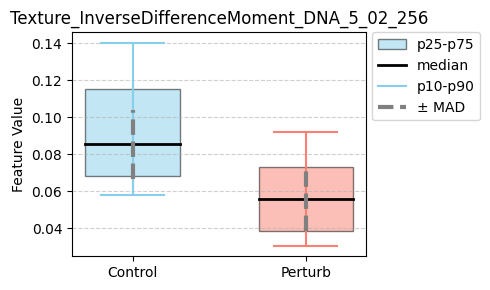

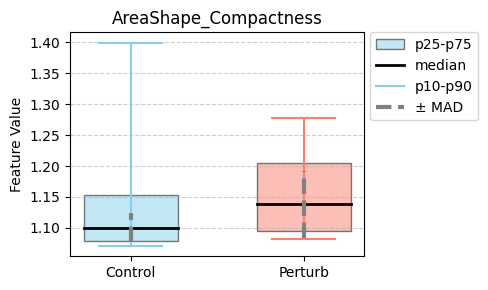

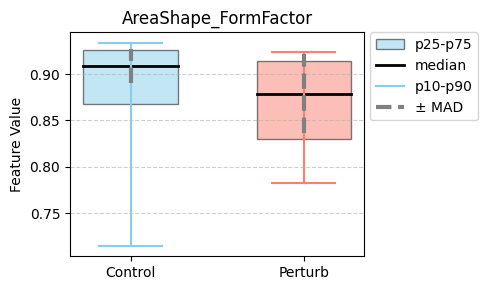

In [ ]:
report_response = analyzer.step3_generate_consistency_prediction()
report_copy = dict(report_response)  # shallow copy
answer_text = report_copy.pop("answer", "")
print(f"\n--- Step 3: Report (without answer) ---")
print(json.dumps(report_copy, indent=2, ensure_ascii=False))
print(f"\n--- LLM Answer (raw) ---")
print(answer_text)

with suppress(Exception):
    parsed = analyzer._extract_json_from_markdown(answer_text)
    print(f"\n--- Parsed Answer ---")
    print(json.dumps(parsed, indent=2, ensure_ascii=False))

figures = analyzer.step4_plot_supporting_features()
for j, fig in enumerate(figures):
    fig.show()
print(f"\n{model_name} completed for {experiment}\n")